In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = sns.load_dataset('titanic')

In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
df['age'] = df['age'].fillna(df['age'].mean())
df['deck'] = df['deck'].fillna(df['deck'].mode()[0])

<Axes: >

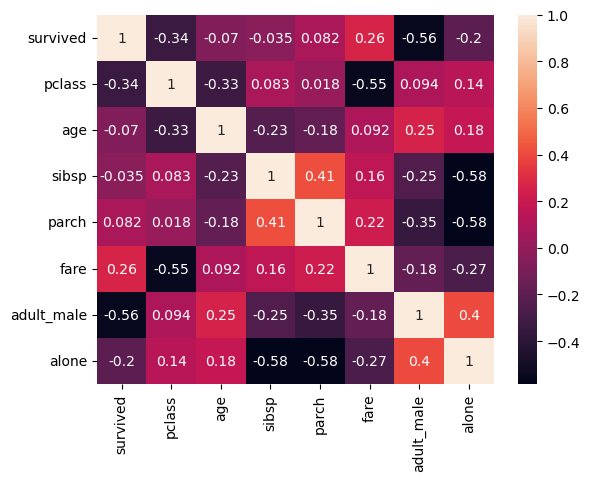

In [8]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='embark_town', ylabel='count'>

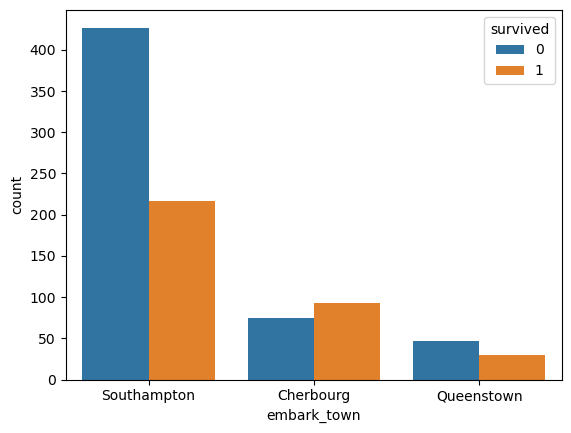

In [9]:
sns.countplot(x=df['embark_town'],hue=df['survived'])

In [10]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [11]:
df['deck'].unique()

['C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [12]:
df = df.drop(columns=['embarked', 'class', 'who', 'adult_male', 'deck','alive', 'alone'])

In [13]:
df.shape

(891, 8)

In [14]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embark_town'],
      dtype='object')

In [17]:
categorical_cols = ['sex','embark_town']
numerical_cols = ['age', 'sibsp', 'parch', 'fare', 'pclass']

In [18]:
df = pd.get_dummies(data=df,columns=categorical_cols,dtype=float,drop_first=True)

In [19]:
x=df.drop(columns=['survived'])
y=df['survived']

In [20]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=42,stratify=y) 

In [21]:
from imblearn.over_sampling import SMOTE
print('Before Smote')
print(y_train.value_counts()) 

smote = SMOTE(random_state=42)
x_train_balanced , y_train_balanced = smote.fit_resample(x_train,y_train)
print("\nAfter SMOTE")
print(y_train_balanced.value_counts()) 

Before Smote
survived
0    412
1    256
Name: count, dtype: int64

After SMOTE
survived
1    412
0    412
Name: count, dtype: int64


<Axes: xlabel='age', ylabel='pclass'>

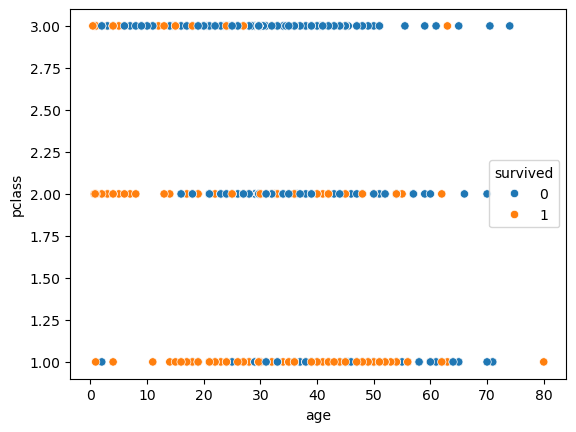

In [23]:
sns.scatterplot(x=df['age'],y=df['pclass'],hue=df['survived'])

In [24]:
from sklearn.naive_bayes import GaussianNB
guas_nb = GaussianNB()
guas_nb.fit(x_train_balanced,y_train_balanced)

,priors,None
,var_smoothing,1e-09


In [25]:
y_pred = guas_nb.predict(x_test)

In [30]:
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
precision_score,
recall_score,
f1_score
)
cm = confusion_matrix(y_test,y_pred)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(cm)

Accuracy : 0.7623318385650224
Precision: 0.6813186813186813
Recall : 0.7209302325581395
F1 Score : 0.7005649717514124
[[108  29]
 [ 24  62]]


# Logistic Regression 

In [29]:
from sklearn.linear_model import LogisticRegression 
lg = LogisticRegression(max_iter=1000)
lg.fit(x_train_balanced,y_train_balanced)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_pred2 = lg.predict(x_test)

In [33]:
cm2 = confusion_matrix(y_test,y_pred2)
print("Accuracy :", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall :", recall_score(y_test, y_pred2))
print("F1 Score :", f1_score(y_test, y_pred2))
print(cm2)

Accuracy : 0.7847533632286996
Precision: 0.6979166666666666
Recall : 0.7790697674418605
F1 Score : 0.7362637362637363
[[108  29]
 [ 19  67]]


# KNN

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_balanced = scaler.fit_transform(x_train_balanced)
x_test = scaler.transform(x_test)

C:\Users\susha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [36]:
from sklearn.neighbors import KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_balanced,y_train_balanced)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
y_pred3 = knn.predict(x_test)

print("First 20 predictions:")
print(y_pred3[:20])
print("\nFirst 20 actual values:")
print(y_test.values[:20]) 

First 20 predictions:
[0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0]

First 20 actual values:
[0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 1 1]


In [38]:
print("Accuracy :", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))
print("Recall :", recall_score(y_test, y_pred3))
print("F1 Score :", f1_score(y_test, y_pred3)) 
cm3 = confusion_matrix(y_test,y_pred3)

Accuracy : 0.6098654708520179
Precision: 0.4962962962962963
Recall : 0.7790697674418605
F1 Score : 0.6063348416289592


In [39]:
from sklearn.model_selection import GridSearchCV
param_grid = {
'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
'weights': ['uniform', 'distance'],
'metric': ['euclidean', 'manhattan']
}
grid_search = GridSearchCV(
estimator=KNeighborsClassifier(),
param_grid=param_grid,
cv=5,
scoring='accuracy',
n_jobs=-1
)
grid_search.fit(x_train_balanced, y_train_balanced)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}

Best Cross-Validation Score:
0.8118773096821877
